**Name** Yasser Khan

**Z-Number** Z23971583

In [ ]:
# @title
import networkx as nx
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Twitch Network") \
    .getOrCreate()
df_edges = spark.read.csv("/content/musae_ENGB_edges.csv", header=True, inferSchema=True)

FROM_COLUMN = "from"
TO_COLUMN = "to"

G = nx.Graph()
for row in df_edges.select(FROM_COLUMN, TO_COLUMN).toLocalIterator():
    G.add_edge(row[FROM_COLUMN], row[TO_COLUMN])

number_of_edges = G.number_of_edges()

print(f"{'Number of nodes:':<35} {G.number_of_nodes():>10,}")
print(f"{'Number of edges:':<35} {G.number_of_edges():>10,}")
print(f"{'Average clustering coefficient:':<35} {nx.average_clustering(G):>10.4f}")
print(f"{'Number of connected components:':<35} {nx.number_connected_components(G):>10}")

Number of nodes:                         7,126
Number of edges:                        35,324
Average clustering coefficient:         0.1309
Number of connected components:              1


In [ ]:
# @title
non_edges = list(nx.non_edges(G))
print(f"Non-edges length: {len(non_edges)}")

Non-edges length: 25351051


In [ ]:
# @title
# 1. Create negative edge samples by randomly sampling non-connected node pairs.
import random

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
negative_samples = random.sample(non_edges, number_of_edges)

print(f"Negative edge samples length: {len(negative_samples)}")
print(negative_samples[:5])

Negative edge samples length: 35324
[(4332, 5718), (545, 6707), (118, 6637), (6156, 6918), (1443, 1541)]


In [ ]:
# @title
# 2. Combine positive and negative samples into a single Spark DataFrame.
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# combine positive samples with label 1 and negative samples with label 0
samples = [(u, v, 1) for u, v in G.edges()] + \
          [(u, v, 0) for u, v in negative_samples]

print(f"Length of samples {len(samples)}")

# create spark data frame
TARGET_COLUMN = "link"

schema = StructType([
    StructField(FROM_COLUMN, IntegerType(), False),
    StructField(TO_COLUMN, IntegerType(), False),
    StructField(TARGET_COLUMN, IntegerType(), False)
])

df_samples = spark.createDataFrame(samples, schema)

df_samples.printSchema()
df_samples.show(5)

Length of samples 70648
root
 |-- from: integer (nullable = false)
 |-- to: integer (nullable = false)
 |-- link: integer (nullable = false)

+----+----+----+
|from|  to|link|
+----+----+----+
|6194| 255|   1|
|6194| 980|   1|
|6194|2992|   1|
|6194|2507|   1|
|6194| 986|   1|
+----+----+----+
only showing top 5 rows


In [ ]:
# @title
# 3. Make sure to shuffle the dataframe.
from pyspark.sql import functions as pysf

df_samples = df_samples.orderBy(pysf.rand(seed=RANDOM_SEED))
df_samples.show(5)

+----+----+----+
|from|  to|link|
+----+----+----+
|5569| 430|   1|
|3530|6222|   0|
|4191|  94|   1|
| 319|3661|   0|
|1482|6789|   0|
+----+----+----+
only showing top 5 rows


+----+-----+
|link|count|
+----+-----+
|   1|35324|
|   0|35324|
+----+-----+



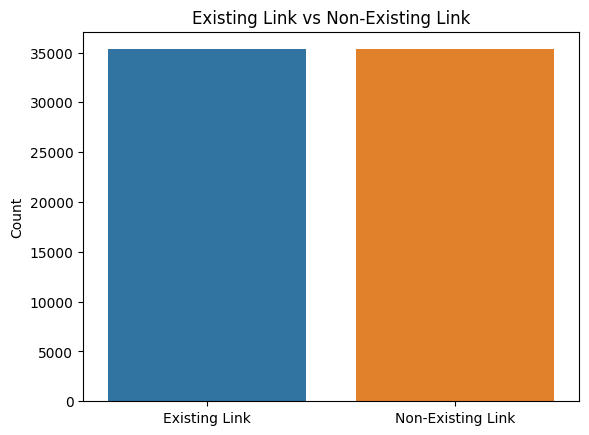

In [ ]:
# @title
# 4. Create a bar chart showing the number of existing vs non-existing edges.
import seaborn as sns
import matplotlib.pyplot as plt

df_samples.groupBy(TARGET_COLUMN).count().show()

follow_group_counts = df_samples.groupBy(TARGET_COLUMN).count().collect()

EXISTING_LABEL = "Existing Link"
NON_EXISTING_LABEL = "Non-Existing Link"

follow_group_labels = [EXISTING_LABEL if r[TARGET_COLUMN] == 1 else NON_EXISTING_LABEL for r in follow_group_counts]

sns.barplot(
    hue=follow_group_labels,
    x=follow_group_labels,
    y=[r["count"] for r in follow_group_counts],
)
plt.title(f"{EXISTING_LABEL} vs {NON_EXISTING_LABEL}")
plt.ylabel("Count")
plt.show()

#### 5. Add a markdown cell commenting on whether the dataset is balanced.
The dataset is balanced, with equal number of existing (35,324) and non-existing (35,324) edges. This is expected since we intentionally sampled the same number of negative edges as positive edges.

In [ ]:
# @title
# 6. Compute similarity measures between each node pair in the dataframe using networkX
from pyspark.sql.types import DoubleType

rows = df_samples.collect()

node_pairs = [(r[FROM_COLUMN], r[TO_COLUMN]) for r in rows]

def compute_similarity(similarity_func):
    return {(from_node, to_node): score for from_node, to_node, score in similarity_func(G, node_pairs)}

jaccard_coefficients = compute_similarity(nx.jaccard_coefficient)
adamic_adars = compute_similarity(nx.adamic_adar_index)
preferential_attachments = compute_similarity(nx.preferential_attachment)

features = []
for row in rows:

    from_node, to_node, follow = row[FROM_COLUMN], row[TO_COLUMN], row[TARGET_COLUMN]

    common_neighbors = len(list(nx.common_neighbors(G, from_node, to_node)))

    node_pair = (from_node, to_node)

    jaccard_coefficient = float(jaccard_coefficients[node_pair])
    adamic_adar = float(adamic_adars[node_pair])
    preferential_attachment = preferential_attachments[node_pair]

    features.append((
        from_node,
        to_node,
        common_neighbors,
        jaccard_coefficient,
        adamic_adar,
        preferential_attachment,
        follow))

COMMON_NEIGHBORS_COLUMN = "common_neighbors"
JACCCARD_COEFFICIENT_COLUMN = "jaccard_coefficient"
ADAMIC_ADAR_COLUMN = "adamic_adar"
PREFERENTIAL_ATTACHMENT_COLUMN = "preferential_attachment"

features_schema = StructType([
    StructField(FROM_COLUMN, IntegerType(), False),
    StructField(TO_COLUMN, IntegerType(), False),
    StructField(COMMON_NEIGHBORS_COLUMN, IntegerType(), False),
    StructField(JACCCARD_COEFFICIENT_COLUMN, DoubleType(), False),
    StructField(ADAMIC_ADAR_COLUMN, DoubleType(), False),
    StructField(PREFERENTIAL_ATTACHMENT_COLUMN, IntegerType(), False),
    StructField(TARGET_COLUMN, IntegerType(), False)
])

df_features = spark.createDataFrame(features, features_schema)
df_features.show(5)

+----+----+----------------+-------------------+------------------+-----------------------+----+
|from|  to|common_neighbors|jaccard_coefficient|       adamic_adar|preferential_attachment|link|
+----+----+----------------+-------------------+------------------+-----------------------+----+
|5569| 430|               8|0.04878048780487805|2.0055296869233223|                   7200|   1|
|3530|6222|               0|                0.0|               0.0|                      9|   0|
|4191|  94|               6|0.06521739130434782|1.2672666213883563|                   1776|   1|
| 319|3661|               0|                0.0|               0.0|                     36|   0|
|1482|6789|               0|                0.0|               0.0|                    198|   0|
+----+----+----------------+-------------------+------------------+-----------------------+----+
only showing top 5 rows


In [ ]:
import pandas as pd

pdf = pd.DataFrame(features, columns=[
    FROM_COLUMN,
    TO_COLUMN,
    COMMON_NEIGHBORS_COLUMN,
    JACCCARD_COEFFICIENT_COLUMN,
    ADAMIC_ADAR_COLUMN,
    PREFERENTIAL_ATTACHMENT_COLUMN,
    TARGET_COLUMN,
])

pdf.to_csv("twitch.csv", index=False)

In [ ]:
df_features.coalesce(1).write.csv("twitch", header=True)

In [ ]:
# @title
# 7. For each similarity measure, create boxplots grouped by the target variable (whether the edge exists or not).
import numpy as np

def plot_similarity_by_target(similarity_column):
  similarity_scores = []
  target_labels = []

  existing_edge_scores = []
  non_existing_edge_scores = []

  for row in df_features.select(similarity_column, TARGET_COLUMN).toLocalIterator():
    score = row[similarity_column]
    follow = row[TARGET_COLUMN]

    similarity_scores.append(score)

    target_labels.append(EXISTING_LABEL if follow == 1 else NON_EXISTING_LABEL)

    if follow == 1:
        existing_edge_scores.append(score)
    else:
        non_existing_edge_scores.append(score)

  def report_summary(label_type, scores):
    print(f"\n{similarity_column} {label_type} summary:")
    print(f"min   : {np.min(scores):.8f}")
    print(f"Q1    : {np.quantile(scores, 0.25):.8f}")
    print(f"median: {np.median(scores):.8f}")
    print(f"Q3    : {np.quantile(scores, 0.75):.8f}")
    print(f"max   : {np.max(scores):.8f}")
    print(f"IQR   : {(np.quantile(scores, 0.75) - np.quantile(scores, 0.25)):.8f}")

  report_summary("Existing link", existing_edge_scores)
  report_summary("Non-existing link", non_existing_edge_scores)

  plt.figure(figsize=(8, 5))
  sns.boxplot(
      hue=target_labels,
      y=target_labels,
      x=similarity_scores,
      order=[NON_EXISTING_LABEL, EXISTING_LABEL],
      hue_order=[NON_EXISTING_LABEL, EXISTING_LABEL],
      palette={NON_EXISTING_LABEL: '#1f77b4', EXISTING_LABEL: '#ff7f0e' },
      legend=True
    )
  plt.xscale('log')
  plt.yticks([])
  display_name = similarity_column.replace("_", " ").title()

  plt.title(f"{display_name} by Link Status")
  plt.xlabel(f"{display_name} (log scale)")
  plt.show()


common_neighbors Existing link summary:
min   : 0.00000000
Q1    : 0.00000000
median: 1.00000000
Q3    : 3.00000000
max   : 134.00000000
IQR   : 3.00000000

common_neighbors Non-existing link summary:
min   : 0.00000000
Q1    : 0.00000000
median: 0.00000000
Q3    : 0.00000000
max   : 19.00000000
IQR   : 0.00000000


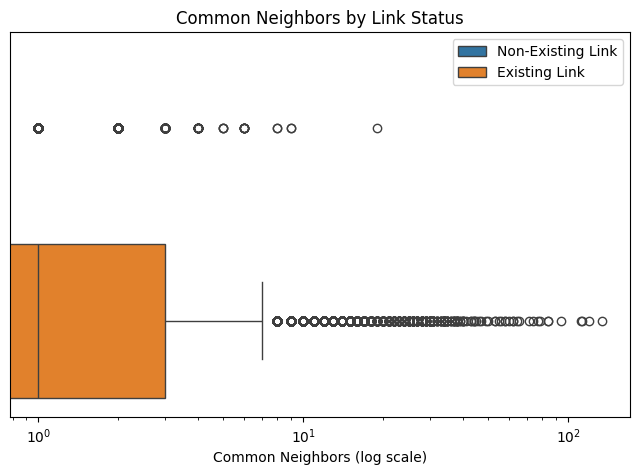

In [ ]:
# @title
# 7. For each similarity measure, create boxplots grouped by the target variable (whether the edge exists or not).

plot_similarity_by_target(COMMON_NEIGHBORS_COLUMN)

#### 8. Under each boxplot, add a markdown cell to discuss differences between positive and negative samples.

The plot shows most positive samples have a small number of common neighbors. 50% of connected Twitch user pairs share at most 1 mutual neighbor, and 75% share 3 or fewer.

The plot shows vast majority of the negative samples have no common neighbors.


jaccard_coefficient Existing link summary:
min   : 0.00000000
Q1    : 0.00000000
median: 0.01250000
Q3    : 0.04918033
max   : 0.60000000
IQR   : 0.04918033

jaccard_coefficient Non-existing link summary:
min   : 0.00000000
Q1    : 0.00000000
median: 0.00000000
Q3    : 0.00000000
max   : 0.50000000
IQR   : 0.00000000


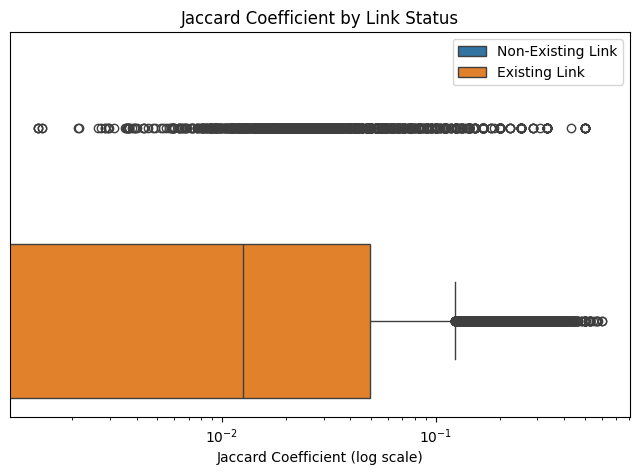

In [ ]:
# @title
# 7. For each similarity measure, create boxplots grouped by the target variable (whether the edge exists or not).

plot_similarity_by_target(JACCCARD_COEFFICIENT_COLUMN)

#### 8. Under each boxplot, add a markdown cell to discuss differences between positive and negative samples.

The plot shows positive samples have very low neighborhood overlap. For half of connected Twitch user pairs, the Jaccard similarity is approximately 1% or lower.

Jaccard similarity is 0 for the vast majority of negative samples, indicating that most non-connected Twitch user pairs share no neighborhood overlap.


adamic_adar Existing link summary:
min   : 0.00000000
Q1    : 0.00000000
median: 0.29697420
Q3    : 0.87349526
max   : 71.00048042
IQR   : 0.87349526

adamic_adar Non-existing link summary:
min   : 0.00000000
Q1    : 0.00000000
median: 0.00000000
Q3    : 0.00000000
max   : 5.05595350
IQR   : 0.00000000


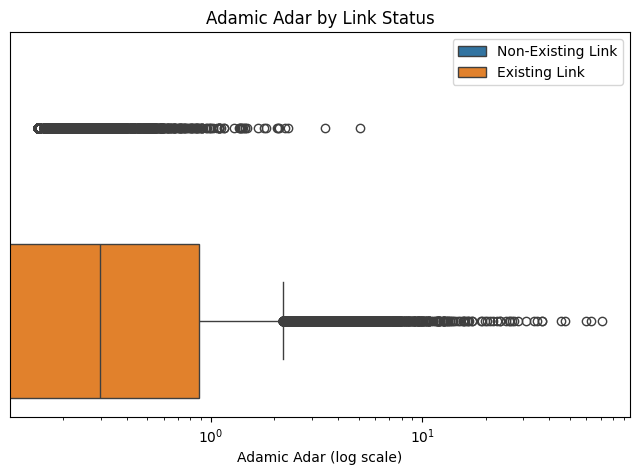

In [ ]:
# @title
# 7. For each similarity measure, create boxplots grouped by the target variable (whether the edge exists or not).

plot_similarity_by_target(ADAMIC_ADAR_COLUMN)

#### 8. Under each boxplot, add a markdown cell to discuss differences between positive and negative samples.

The plot shows positive samples have very low neighborhood overlap. For half of connected Twitch user pairs, the Adamic-Adar similarity is 0.3 or lower.

Adamic-Adar similarity is 0 for the vast majority of negative samples, indicating that most non-connected Twitch user pairs share no neighborhood overlap.


preferential_attachment Existing link summary:
min   : 2.00000000
Q1    : 160.00000000
median: 528.00000000
Q3    : 1620.00000000
max   : 334800.00000000
IQR   : 1460.00000000

preferential_attachment Non-existing link summary:
min   : 1.00000000
Q1    : 8.00000000
median: 22.00000000
Q3    : 68.00000000
max   : 34020.00000000
IQR   : 60.00000000


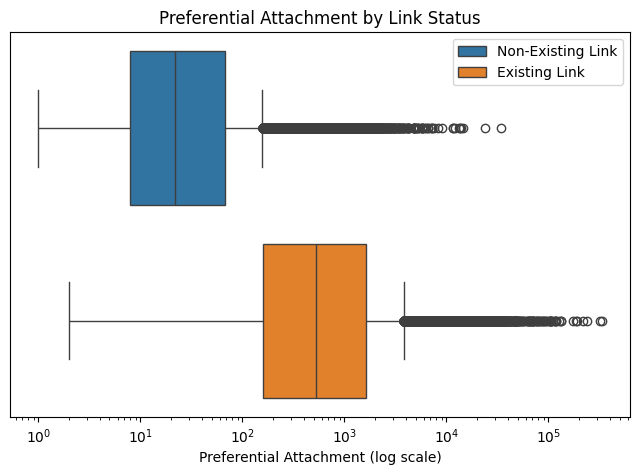

In [ ]:
# @title
# 7. For each similarity measure, create boxplots grouped by the target variable (whether the edge exists or not).

plot_similarity_by_target(PREFERENTIAL_ATTACHMENT_COLUMN)

#### 8. Under each boxplot, add a markdown cell to discuss differences between positive and negative samples.

Positive samples have a median preferential attachment of 528 while negative samples have a median of 22. Since preferential attachment measures the product of degrees, the plot indicates that connections are more likely to involve higher degree Twitch users. Non-connected pairs typically involve users with much lower degrees.

In [ ]:
# @title
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col

feature_columns = [COMMON_NEIGHBORS_COLUMN, JACCCARD_COEFFICIENT_COLUMN, ADAMIC_ADAR_COLUMN, PREFERENTIAL_ATTACHMENT_COLUMN]
FEATURES_COLUMN = "similarity_scores"

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol=FEATURES_COLUMN,
)

df_ml = assembler.transform(df_features).select(FEATURES_COLUMN, col(TARGET_COLUMN))
df_ml.show(5, truncate=False)

+---------------------------------------------------+----+
|similarity_scores                                  |link|
+---------------------------------------------------+----+
|[8.0,0.04878048780487805,2.0055296869233223,7200.0]|1   |
|(4,[3],[9.0])                                      |0   |
|[6.0,0.06521739130434782,1.2672666213883563,1776.0]|1   |
|(4,[3],[36.0])                                     |0   |
|(4,[3],[198.0])                                    |0   |
+---------------------------------------------------+----+
only showing top 5 rows


In [ ]:
# @title
# 9. Split the dataset into training and testing sets.

df_train, df_test = df_ml.randomSplit([0.8, 0.2], seed=RANDOM_SEED)

print(f"Training set: {df_train.count()} rows")
print(f"Testing set: {df_test.count()} rows")

Training set: 56605 rows
Testing set: 14043 rows


In [ ]:
# 10. Train a logistic regression model using PySpark by performing 5-fold cross-validation

from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
sc = spark.sparkContext

metric_configs = [
    ("AUC", "areaUnderROC", None),
    ("Accuracy", "accuracy", None),
    ("Weighted Precision", "weightedPrecision", None),
    ("Weighted Recall", "weightedRecall", None),
    ("F1-score", "f1", None),
]

metrics = {}

for name, metric, label in metric_configs:
    if name == "AUC":
        evaluator = BinaryClassificationEvaluator(
            labelCol=TARGET_COLUMN,
            metricName=metric)
    else:
        evaluator = MulticlassClassificationEvaluator(
            labelCol=TARGET_COLUMN,
            metricName=metric,
            metricLabel=label)

    metrics[name] = {"evaluator": evaluator, "scores": []}

k = 5
folds = df_train.randomSplit([0.2]*k)

lr = LogisticRegression(labelCol=TARGET_COLUMN, featuresCol=FEATURES_COLUMN)

for i in range(k):
    test_fold = folds[i]
    train_fold = spark.createDataFrame(sc.emptyRDD(), df_train.schema)

    for j in range(k):
        if j != i:
            train_fold = train_fold.union(folds[j])

    model = lr.fit(train_fold)
    preds = model.transform(test_fold)

    for m in metrics.values():
      score = m["evaluator"].evaluate(preds)
      m["scores"].append(score)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 11. Report average cross-validation metrics.

for name, m in metrics.items():
    avg = sum(m["scores"])/len(m["scores"])
    print(f"Average {name + ':':<25} {avg:.2f}")

Average AUC:                      0.92
Average Accuracy:                 0.83
Average Weighted Precision:       0.85
Average Weighted Recall:          0.83
Average F1-score:                 0.83


In [ ]:
# 12. Train the model on the whole training set and generate predictions on the test set.

d

+-----------------+----+----------+---------------------------------------+
|similarity_scores|link|prediction|probability                            |
+-----------------+----+----------+---------------------------------------+
|(4,[3],[1.0])    |0   |0.0       |[0.8000688759428567,0.1999311240571433]|
|(4,[3],[1.0])    |0   |0.0       |[0.8000688759428567,0.1999311240571433]|
|(4,[3],[1.0])    |0   |0.0       |[0.8000688759428567,0.1999311240571433]|
|(4,[3],[1.0])    |0   |0.0       |[0.8000688759428567,0.1999311240571433]|
|(4,[3],[1.0])    |0   |0.0       |[0.8000688759428567,0.1999311240571433]|
+-----------------+----+----------+---------------------------------------+
only showing top 5 rows


In [ ]:
# 13. Report accuracy, precision, recall, and F1-score on the test set.

class_level_metric_configs = [
    ("Precision (link)", "precisionByLabel", 1.0),
    ("Recall (link)", "recallByLabel", 1.0),
    ("F1-score (link)", "fMeasureByLabel", 1.0),

    ("Precision (non-link)", "precisionByLabel", 0.0),
    ("Recall (non-link)", "recallByLabel", 0.0),
    ("F1-score (non-link)", "fMeasureByLabel", 0.0),
]

for name, metric, label in class_level_metric_configs:
    evaluator = MulticlassClassificationEvaluator(
      labelCol=TARGET_COLUMN,
      metricName=metric,
      metricLabel=label)

    metrics[name] = {"evaluator": evaluator }

for name, m in metrics.items():
  evaluator = metrics[name]["evaluator"]
  score = m["evaluator"].evaluate(preds)

  print(f"{name + ':':<25} {score:.2f}")

AUC:                      0.92
Accuracy:                 0.84
Weighted Precision:       0.86
Weighted Recall:          0.84
F1-score:                 0.84
Precision (link):         0.94
Recall (link):            0.73
F1-score (link):          0.82
Precision (non-link):     0.77
Recall (non-link):        0.95
F1-score (non-link):      0.85


#### 14. Add a markdown cell interpreting the results.

The model achieves on average 84% accuracy on the test set. The model is better at identifying
non-links than links.

From the recall, we can say the model correctly identifying 95% of non-links. However, it missed 27% of existing links.

From the precision, we can say the model has high precision (94%) in identifying existing links. However, for non-links, the model has many false positives (23%).

The F1-scores are reasonably balanced (0.82 vs 0.85) showing the model performs adequately for both classes.

In [ ]:
coefficients = model.coefficients.toArray()

for name, coef in zip(feature_columns, coefficients):
    print(f"{name}: {coef:.3f}")

common_neighbors: -0.976
jaccard_coefficient: -3.113
adamic_adar: 10.356
preferential_attachment: 0.003
